# Comparison of evolutionary rescue via biological and cultural evolution

This notebook contains the source code to proudces figures and tables in the manuscript.
The simulation codes are available from python source codes in other files.

In [1]:
import pandas as pd
import numpy as np
import scipy
import statsmodels
import sys
import matplotlib.pyplot as plt
import sklearn

print("Python version:", sys.version)
print("pandas", pd.__version__)
print("numpy", np.__version__)
print("scipy", scipy.__version__)
print("statsmodels", statsmodels.__version__)
print("sklearn", sklearn.__version__)

Python version: 3.11.12 (main, Apr  8 2025, 14:15:29) [Clang 16.0.0 (clang-1600.0.26.6)]
pandas 2.2.3
numpy 2.2.6
scipy 1.15.3
statsmodels 0.14.4
sklearn 1.9.0


# Without any evolutioanry processes
## Figure S1
Confirmation of population extinction without evolution

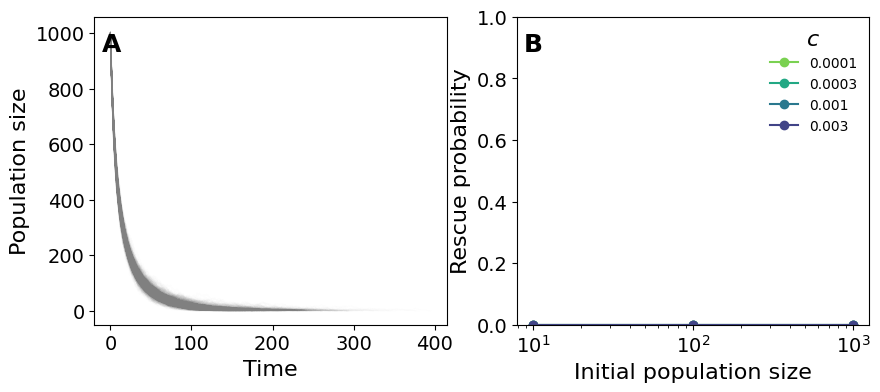

In [2]:
import seaborn as sns
from scipy.stats import beta
import string
def beta_credible_interval(row, alpha=0.05):
    a = 1 + row["rescue"]
    b = 1 + row["extinction"]
    lower = beta.ppf(alpha / 2, a, b)
    upper = beta.ppf(1 - alpha / 2, a, b)
    return pd.Series({
        "rescue_prob": row["rescue"] / (row["rescue"] + row["extinction"]),
        "ci_lower": lower,
        "ci_upper": upper
    })

def scatter_with_ci(data, color, **kwargs):
    plt.scatter(
        data["b_A"],
        data["rescue_prob"],
        color=color,
        s=70,
        zorder=3
    )
    plt.vlines(
        data["b_A"],
        data["ci_lower"],
        data["ci_upper"],
        color=color,
        linewidth=1
    )
def format_mu(mu):   
    if mu == 0:        
        return r"$0$"    
    else:        
        return rf"$10^{{{int(np.log10(mu))}}}$"
    
df_base=pd.read_csv('BaselineModel.csv')
df_traj=pd.read_csv('BaselineModel_Trajectories.csv')
df_base[["rescue_prob", "ci_lower", "ci_upper"]] = df_base.apply(beta_credible_interval, axis=1)
df_base["c_label"] = df_base["c"].map(lambda x: f"{x:.6f}".rstrip("0").rstrip("."))
fig, axs = plt.subplot_mosaic(
    [["traj", "prob"]],          # 1行2列
    figsize=(10, 4),
    gridspec_kw={"width_ratios": [1, 1]}
)

ax_traj = axs["traj"]   # 左：trajectory
ax_prob = axs["prob"]   # 右：rescue probability
for traj_id, df_one in df_traj.groupby("traj_id"):
    ax_traj.plot(
        df_one["time"],
        df_one["pop_total"],
        color="grey",
        alpha=0.01,
        linewidth=0.8
    )

ax_traj.set_xlabel("Time", fontsize=16)
ax_traj.set_ylabel("Population size", fontsize=16)


groups = list(df_base.groupby("c"))
palette = sns.color_palette("viridis_r", n_colors=len(groups))

for (color, (c_val, df_c)) in zip(palette, groups):

    label = f"{c_val:.6f}".rstrip("0").rstrip(".")

    ax_prob.plot(
        df_c["init_pop_size"],
        df_c["rescue_prob"],
        marker="o",
        color=color,
        label=label
    )

    ax_prob.vlines(
        x=df_c["init_pop_size"],
        ymin=df_c["ci_lower"],
        ymax=df_c["ci_upper"],
        color=color,      # <- これも揃えると見やすい
        linewidth=1,
        alpha=0.9
    )
ax_prob.set_xscale("log")
ax_prob.set_xlabel("Initial population size", fontsize=16)
ax_prob.set_ylabel("Rescue probability", fontsize=16)
ax_prob.set_ylim(0, 1)
leg = ax_prob.legend(
    title="$c$",
    frameon=False,
    loc="upper right"
)
leg.get_title().set_fontsize(16)
for ax in axs.values(): 
    ax.tick_params(axis="both", which="major", labelsize=14)
panel_labels = string.ascii_uppercase  # 'A', 'B', 'C', ...


labels = {"traj": "A", "prob": "B"}

for key, label in labels.items():
    ax = axs[key]
    ax.text(
        0.02, 0.95, label,
        transform=ax.transAxes, 
        fontsize=18,
        fontweight="bold",
        va="top",
        ha="left"
    )

#plt.savefig('Baseline_Model_Results.png', bbox_inches='tight')

## Figure S7
Probability of population persistence when the population consists only of adaptive individauls and the no evolutionary processes are included.

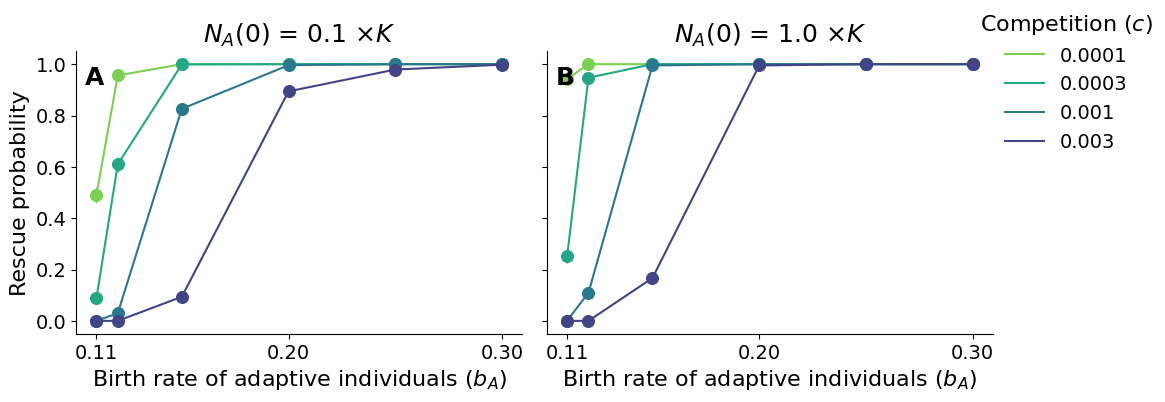

In [3]:
# analysis of the "rescue" probablity when only adaptive indivudauls exist and no evolution occurs
import seaborn as sns
from scipy.stats import beta
import string


def beta_credible_interval(row, alpha=0.05):
    a = 1 + row["rescue"]
    b = 1 + row["extinction"]
    lower = beta.ppf(alpha / 2, a, b)
    upper = beta.ppf(1 - alpha / 2, a, b)
    return pd.Series({
        "rescue_prob": row["rescue"] / (row["rescue"] + row["extinction"]),
        "ci_lower": lower,
        "ci_upper": upper
    })

def scatter_with_ci(data, color, **kwargs):
    plt.scatter(
        data["b_A"],
        data["rescue_prob"],
        color=color,
        s=70,
        zorder=3
    )
    plt.vlines(
        data["b_A"],
        data["ci_lower"],
        data["ci_upper"],
        color=color,
        linewidth=1
    )
def format_mu(mu):   
    if mu == 0:        
        return r"$0$"    
    else:        
        return rf"$10^{{{int(np.log10(mu))}}}$"
        
df=pd.read_csv('BaselineModel_adaptive.csv')
#df_drift=df[(df["init_fraction"] == 1)].copy() # initial population size = 1 x K
#df_thre=df[(df["init_fraction"] == 0.1)].copy() # initial population size = 0.1 x K


df[["rescue_prob","ci_lower", "ci_upper"]] = df.apply(
    beta_credible_interval,
    axis=1
)
g = sns.FacetGrid(
    df,
    col="init_fraction",
    hue="c",
    col_wrap=2,
    height=4,
    aspect=1.1,
    palette="viridis_r",
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="b_A",
    y="rescue_prob"
)

g.map_dataframe(scatter_with_ci)
for ax in g.axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=14)
g.set_axis_labels(r"Birth rate of adaptive individuals ($b_A$)", "Rescue probability", fontsize=16)
g.set_titles(col_template=r"$N_A(0)$ = {col_name} $\times K$", size=18)
g.set(ylim=(-0.05, 1.05))
g.add_legend(title="Competition ($c$)", prop={"size": 14})
g.legend.set_bbox_to_anchor((1.15, 0.8))
g.legend.set_frame_on(False)
g.legend.get_title().set_fontsize(16)
g.tight_layout(rect=[0, 0, 0.85, 1])
xticks = np.array([0.11, 0.2, 0.3])
for ax in g.axes.flat:
    ax.set_xticks(xticks)

panel_labels = string.ascii_uppercase  # 'A', 'B', 'C', ...

for ax, label in zip(g.axes.flat, panel_labels):
    ax.text(
        0.02, 0.95, label,
        transform=ax.transAxes,  
        fontsize=18,
        fontweight='bold',
        va='top',
        ha='left'
    )

plt.tight_layout()
fname='Baseline_adaptive.pdf'
#plt.savefig(fname, dpi=300, bbox_inches='tight')
plt.show()

# With biological evolution
## Figure 2
Biological evolution can lead to evolutionary rescue

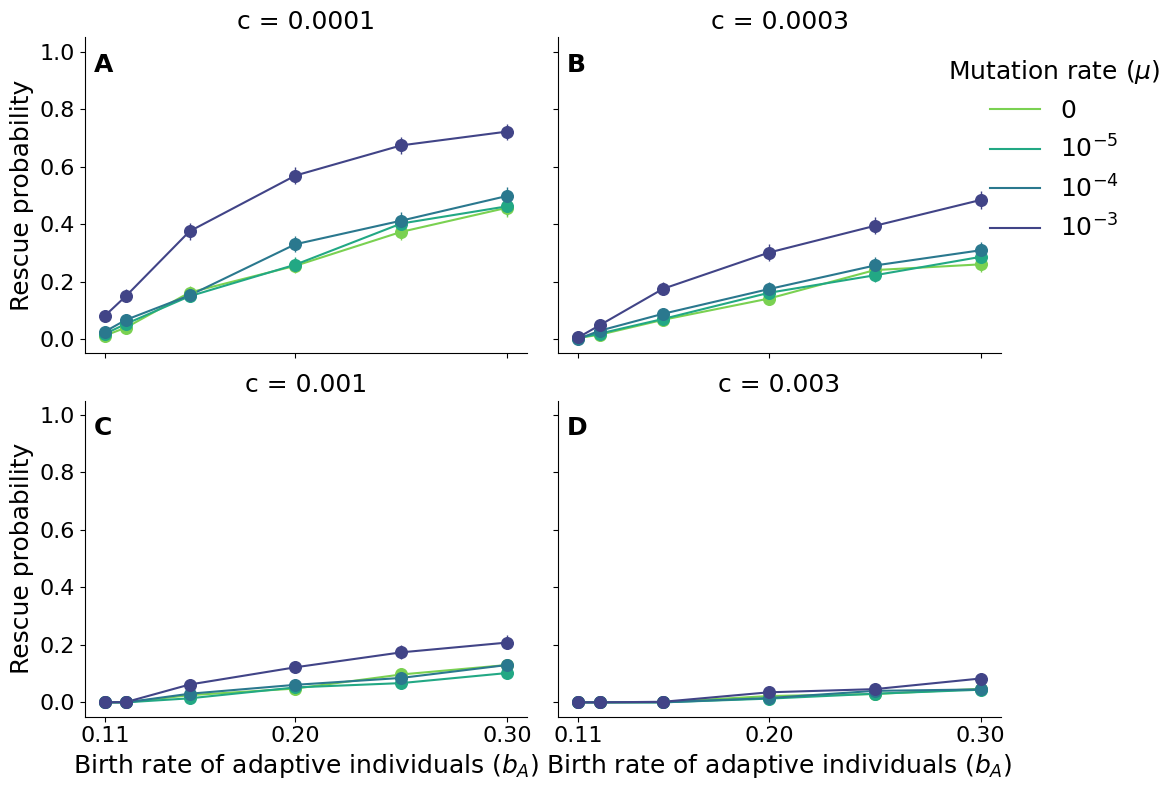

In [2]:
# Plot figures
import seaborn as sns
from scipy.stats import beta
import string


def beta_credible_interval(row, alpha=0.05):
    a = 1 + row["rescue"]
    b = 1 + row["extinction"]
    lower = beta.ppf(alpha / 2, a, b)
    upper = beta.ppf(1 - alpha / 2, a, b)
    return pd.Series({
        "rescue_prob": row["rescue"] / (row["rescue"] + row["extinction"]),
        "ci_lower": lower,
        "ci_upper": upper
    })

def scatter_with_ci(data, color, **kwargs):
    plt.scatter(
        data["b_A"],
        data["rescue_prob"],
        color=color,
        s=70,
        zorder=3
    )
    plt.vlines(
        data["b_A"],
        data["ci_lower"],
        data["ci_upper"],
        color=color,
        linewidth=1
    )
def format_mu(mu):   
    if mu == 0:        
        return r"$0$"    
    else:        
        return rf"$10^{{{int(np.log10(mu))}}}$"
df_bio=pd.read_csv('Biological_evolutionary_rescue.csv')
init_pop=1000
df_plot = df_bio[(df_bio["init_pop_size"] == init_pop)].copy()
df_plot[["rescue_prob","ci_lower", "ci_upper"]] = df_plot.apply(
    beta_credible_interval,
    axis=1
)
c_order = sorted(df_plot["c"].unique())
df_plot["mu_label"] = df_plot["mu"].apply(
    format_mu
)
g = sns.FacetGrid(
    df_plot,
    col="c",
    hue="mu_label",
    col_wrap=2,
    col_order=c_order,   
    height=4,
    aspect=1.1,
    palette="viridis_r",
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="b_A",
    y="rescue_prob"
)

g.map_dataframe(scatter_with_ci)
for ax in g.axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=16)
g.set_axis_labels(r"Birth rate of adaptive individuals ($b_A$)", "Rescue probability", fontsize=18)
g.set_titles(col_template="c = {col_name}", size=18)
g.set(ylim=(-0.05, 1.05))
g.add_legend(title="Mutation rate ($μ$)", prop={"size": 18})
g.legend.set_bbox_to_anchor((1.15, 0.8))
g.legend.set_frame_on(False)
g.legend.get_title().set_fontsize(18)
g.tight_layout(rect=[0, 0, 0.85, 1])
xticks = np.array([0.11, 0.2, 0.3])
for ax in g.axes.flat:
    ax.set_xticks(xticks)

panel_labels = string.ascii_uppercase  # 'A', 'B', 'C', ...

for ax, label in zip(g.axes.flat, panel_labels):
    ax.text(
        0.02, 0.95, label,
        transform=ax.transAxes,  
        fontsize=18,
        fontweight='bold',
        va='top',
        ha='left'
    )

plt.tight_layout()
fname=f'Biological_evolutionary_rescue_plot_init_pop_{init_pop}.pdf'
#plt.savefig(fname, dpi=300, bbox_inches='tight')
plt.show()

## Table S1
The birth rates of adaptive individuals and the mutation rate increase the rescue probability, while the competition coefficient and the initial population size decrease it.

In [4]:
# statistical analysis
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf



df = pd.read_csv("Biological_evolutionary_rescue.csv")
df["log10_mu"] = np.log10(df["mu"] + 1e-10)
df["log10_c"] = np.log10(df["c"])
df["log10_N0"] = np.log10(df["init_pop_size"])
df["rescue_prob"] = df["rescue"] / (df["rescue"] + df["extinction"])

glm = smf.glm(
    "rescue_prob ~ b_A + log10_mu + log10_c + log10_N0",
    data=df,
    family=sm.families.Binomial(),
    freq_weights=df["rescue"] + df["extinction"]
).fit()
coef_table = glm.summary2().tables[1]

print(coef_table.round(3))

            Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
Intercept  -6.546     0.041 -159.683    0.0  -6.627  -6.466
b_A        15.841     0.079  200.084    0.0  15.685  15.996
log10_mu    0.028     0.002   14.895    0.0   0.025   0.032
log10_c    -1.110     0.010 -114.837    0.0  -1.129  -1.091
log10_N0   -0.750     0.007 -114.475    0.0  -0.763  -0.737


## Figure S2
The calibration plot of the above statistical model

/var/folders/pd/r54tyyzj25j1d9xv8skmgd4r0000gn/T/ipykernel_51322/2199613711.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("bin")
/var/folders/pd/r54tyyzj25j1d9xv8skmgd4r0000gn/T/ipykernel_51322/2199613711.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


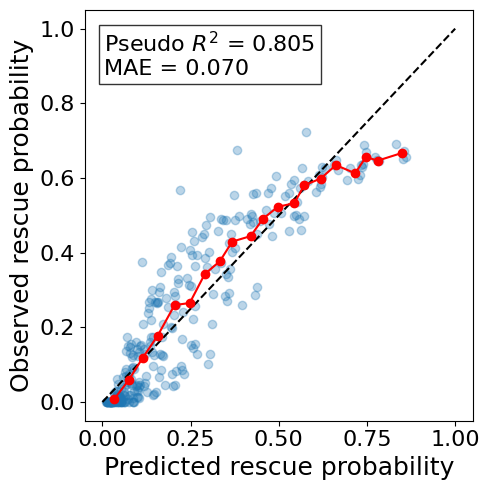

In [5]:
# calibration plot
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import binned_statistic
from sklearn.metrics import mean_absolute_error

def Calibration(df, glm, fname=False):
    df["pred_prob"] = glm.predict(df)
    df["bin"] = pd.qcut(df["pred_prob"], q=20, duplicates="drop")
    calib = (
        df.groupby("bin")
          .apply(lambda x: pd.Series({
              "pred_mean": np.average(x["pred_prob"],
                                      weights=x["rescue"] + x["extinction"]),
              "obs_mean": np.average(x["rescue_prob"],
                                     weights=x["rescue"] + x["extinction"])
          }))
          .reset_index()
    )
    fig, ax = plt.subplots(figsize=(5,5))
    plt.scatter(
        df["pred_prob"],
        df["rescue_prob"],
        alpha=0.3
    )
    plt.plot([0,1],[0,1],"k--", label="Perfect calibration")
    
    
    obs_mean, edges, _ = binned_statistic(
        df["pred_prob"],
        df["rescue_prob"],
        statistic="mean",
        bins=20
    )
    
    pred_mean, _, _ = binned_statistic(
        df["pred_prob"],
        df["pred_prob"],
        statistic="mean",
        bins=20
    )

    pseudo_r2 = 1 - glm.deviance / glm.null_deviance
    mae = mean_absolute_error(df["rescue_prob"],df["pred_prob"])
   
    
    ax.text(0.05, 0.95,
        f"Pseudo $R^2$ = {pseudo_r2:.3f}\n"
        f"MAE = {mae:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=16,
        bbox=dict(
        facecolor="white",
        edgecolor="black",
        alpha=0.8))
    
    
    
    ax.plot(pred_mean, obs_mean, "ro-")
    ax.tick_params(axis='both', which='major', labelsize=16)
    plt.xlabel("Predicted rescue probability", fontsize=18)
    plt.ylabel("Observed rescue probability", fontsize=18)
    plt.tight_layout()
    #if fname !=False:
        #plt.savefig(fname)
    plt.show()
Calibration(df, glm, "Calibration_biological_evolution.eps")

# With cultural evolution
## Individual learning alone
### Figure S6
Population cannot be rescued by individaul learning alone unless its rate is very high.

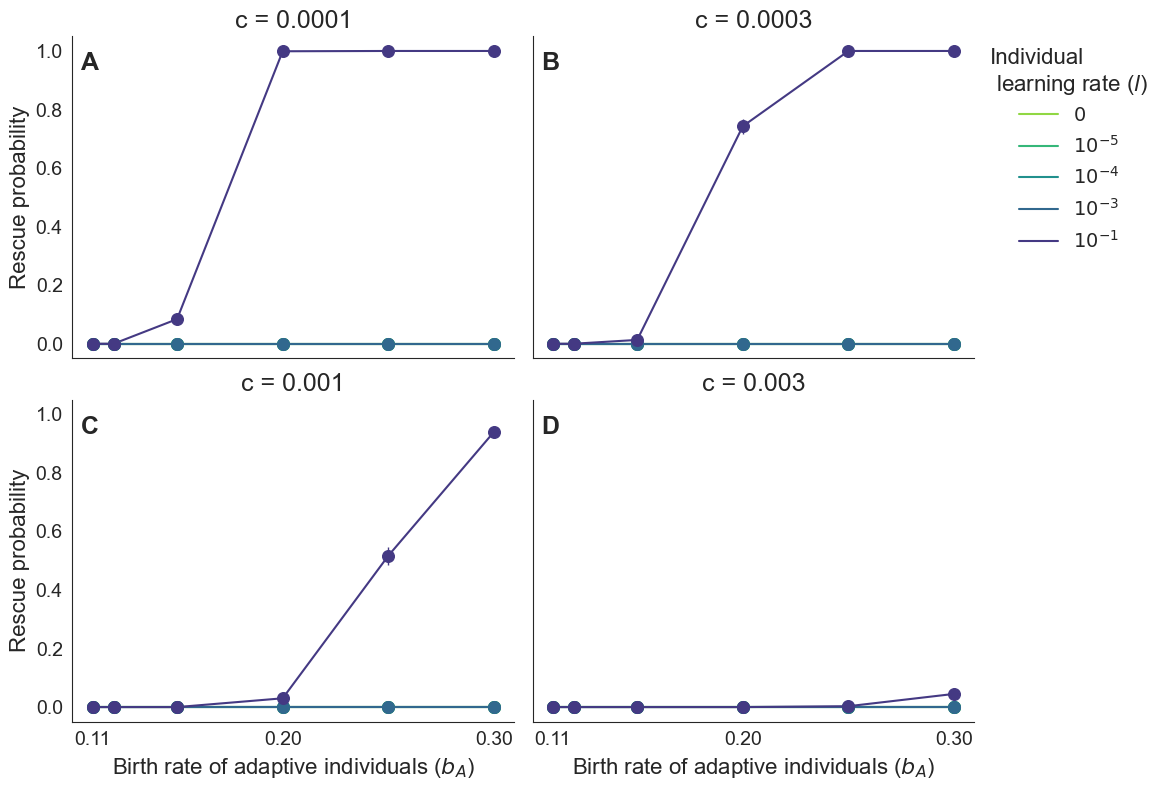

In [7]:
# Plot figures
import seaborn as sns
from scipy.stats import beta
import string


def beta_credible_interval(row, alpha=0.05):
    a = 1 + row["rescue"]
    b = 1 + row["extinction"]
    lower = beta.ppf(alpha / 2, a, b)
    upper = beta.ppf(1 - alpha / 2, a, b)
    return pd.Series({
        "rescue_prob": row["rescue"] / (row["rescue"] + row["extinction"]),
        "ci_lower": lower,
        "ci_upper": upper
    })

def scatter_with_ci(data, color, **kwargs):
    plt.scatter(
        data["b_A"],
        data["rescue_prob"],
        color=color,
        s=70,
        zorder=3
    )
    plt.vlines(
        data["b_A"],
        data["ci_lower"],
        data["ci_upper"],
        color=color,
        linewidth=1
    )
def format_mu(mu):   
    if mu == 0:        
        return r"$0$"    
    else:        
        return rf"$10^{{{int(np.log10(mu))}}}$"
df_cul_ind=pd.read_csv('Cultural_evolutionary_rescue_individual.csv')
init_pop=1000
df_plot = df_cul_ind[(df_cul_ind["init_pop_size"] == init_pop)].copy()
df_plot[["rescue_prob","ci_lower", "ci_upper"]] = df_plot.apply(
    beta_credible_interval,
    axis=1
)
c_order = sorted(df_plot["c"].unique())
df_plot["mu_label"] = df_plot["mu"].apply(
    format_mu
)
sns.set_style("white")
g = sns.FacetGrid(
    df_plot,
    col="c",
    hue="mu_label",
    col_wrap=2,
    col_order=c_order,   
    height=4,
    aspect=1.1,
    palette="viridis_r",
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="b_A",
    y="rescue_prob",
    estimator=None,    
    errorbar=None,   # ← これが決定打
)

g.map_dataframe(scatter_with_ci)
for ax in g.axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=14)
g.set_axis_labels(r"Birth rate of adaptive individuals ($b_A$)", "Rescue probability", fontsize=16)
g.set_titles(col_template="c = {col_name}", size=18)
g.set(ylim=(-0.05, 1.05))
g.add_legend(title="Individual\n learning rate ($l$)", prop={"size": 14})
g.legend.set_bbox_to_anchor((1.17, 0.8))
g.legend.set_frame_on(False)
g.legend.get_title().set_fontsize(16)
g.tight_layout(rect=[0, 0, 0.85, 1])
xticks = np.array([0.11, 0.2, 0.3])
for ax in g.axes.flat:
    ax.set_xticks(xticks)

panel_labels = string.ascii_uppercase  # 'A', 'B', 'C', ...

for ax, label in zip(g.axes.flat, panel_labels):
    ax.text(
        0.02, 0.95, label,
        transform=ax.transAxes,  
        fontsize=18,
        fontweight='bold',
        va='top',
        ha='left'
    )

plt.tight_layout()
fname=f'Cultural_evolutionary_rescue_individual_plot_init_pop_{init_pop}.pdf'
#plt.savefig(fname, dpi=300, bbox_inches='tight')
plt.show()

## Social learning models

In [8]:
import seaborn as sns
from scipy.stats import beta
import string
from matplotlib.lines import Line2D


def beta_credible_interval(row, alpha=0.05):
    a = 1 + row["rescue"]
    b = 1 + row["extinction"]
    lower = beta.ppf(alpha / 2, a, b)
    upper = beta.ppf(1 - alpha / 2, a, b)
    return pd.Series({
        "rescue_prob": row["rescue"] / (row["rescue"] + row["extinction"]),
        "ci_lower": lower,
        "ci_upper": upper
    })

def scatter_with_ci(data, color, **kwargs):
    for k in ["ci", "estimator", "errorbar"]:       
        kwargs.pop(k, None)
    sns.scatterplot(
        data=data,
        x="b_A",
        y="rescue_prob",
        style="s",
        markers={0.00001: "v", 0.001: "o", 0.1: "s", 1: "^"},
        color=color,
        s=70,
        zorder=3,
        legend=False  
    )
    plt.vlines(
        data["b_A"],
        data["ci_lower"],
        data["ci_upper"],
        color=color,
        linewidth=1
    )
def format_mu(mu):   
    if mu == 0:        
        return r"$0$"    
    else:        
        return rf"$10^{{{int(np.log10(mu))}}}$"

def Plot_dynamics(bias_type, init_pop=1000, ind_learning_rate=0):
    if bias_type==0:
        # content bias
        fname="Cultural_evolutionary_rescue_content.csv"
    elif bias_type==1:
        fname="Cultural_evolutionary_rescue_conformity.csv"
    else:
        fname="Cultural_evolutionary_rescue_anticonformity.csv"
        
    df_cul=pd.read_csv(fname)
    df_plot = df_cul[(df_cul["init_pop_size"] == init_pop) 
    &    (df_cul["mu"] == ind_learning_rate)
          ].copy()
    
    df_plot[["rescue_prob","ci_lower", "ci_upper"]] = df_plot.apply(
        beta_credible_interval,
        axis=1
    )
    c_order = sorted(df_plot["c"].unique())
    df_plot["mu_label"] = df_plot["mu"].apply(
        format_mu
    )
    
    g = sns.FacetGrid(
        df_plot,
        col="c",
        hue="parm",
        col_wrap=2,
        col_order=c_order,   
        height=4,
        aspect=1.1,
        palette="viridis_r",
        sharey=True
    )
    
    g.map_dataframe(
        sns.lineplot,
        x="b_A",
        y="rescue_prob",
        estimator=None,   
        errorbar=None,   
        units="s", 
        linewidth=2,
        zorder=2,
    )
    
    g.map_dataframe(scatter_with_ci)
    for ax in g.axes.flat:
        ax.tick_params(axis='both', which='major', labelsize=14)
    g.set_axis_labels(r"Birth rate of adaptive individuals ($b_A$)", "Rescue probability", fontsize=16)
    g.set_titles(col_template="c = {col_name}", size=18)
    g.set(ylim=(-0.05, 1.05))
    if bias_type==0:
        g.add_legend(title="Strength of content bias", prop={"size": 14})
    elif bias_type==1:
         g.add_legend(title="Strength of conformity bias", prop={"size": 14})
    else:
         g.add_legend(title="Strength of anticonformity bias", prop={"size": 14})    
    g.legend.set_bbox_to_anchor((1.17, 0.8))
    g.legend.set_frame_on(False)
    g.legend.get_title().set_fontsize(16)
    g.tight_layout(rect=[0, 0, 0.85, 1])
    xticks = np.array([0.11, 0.2, 0.3])
    for ax in g.axes.flat:
        ax.set_xticks(xticks)
    
    
    shape_legend = [
        Line2D([0], [0], marker="v", linestyle="None", color="black",
               markersize=8, label=r"$s = 10^{-5}$"),
        Line2D([0], [0], marker="o", linestyle="None", color="black",
               markersize=8, label=r"$s = 10^{-3}$"),
        Line2D([0], [0], marker="s", linestyle="None", color="black",
               markersize=8, label=r"$s = 10^{-1}$"),
        Line2D([0], [0], marker="^", linestyle="None", color="black",
               markersize=8, label=r"$s = 1$")
    ]
    
    g.fig.legend(
        handles=shape_legend,
        title="Social learning rate",
        loc="center right",
        bbox_to_anchor=(1.17, 0.35),
        prop={"size": 14},
        title_fontsize=18,
        frameon=False
    )
    
    panel_labels = string.ascii_uppercase  # 'A', 'B', 'C', ...
    
    for ax, label in zip(g.axes.flat, panel_labels):
        ax.text(
            0.02, 0.95, label,
            transform=ax.transAxes,  
            fontsize=18,
            fontweight='bold',
            va='top',
            ha='left'
        )
    
    plt.tight_layout()
    if bias_type==0:
        gname=f'Cultural_evolutionary_rescue_content_individual_learning_{ind_learning_rate}_init_pop_{init_pop}.pdf'
    elif bias_type==1:
        gname=f'Cultural_evolutionary_rescue_conformity_individual_learning_{ind_learning_rate}_init_pop_{init_pop}.pdf'
    else:
         gname=f'Cultural_evolutionary_rescue_anticonformity_individual_learning_{ind_learning_rate}_init_pop_{init_pop}.pdf'
    #plt.savefig(gname, dpi=300, bbox_inches='tight')
    plt.show()

## Content bias
### Figure 3
Content bias facilitates evolutionary rescue

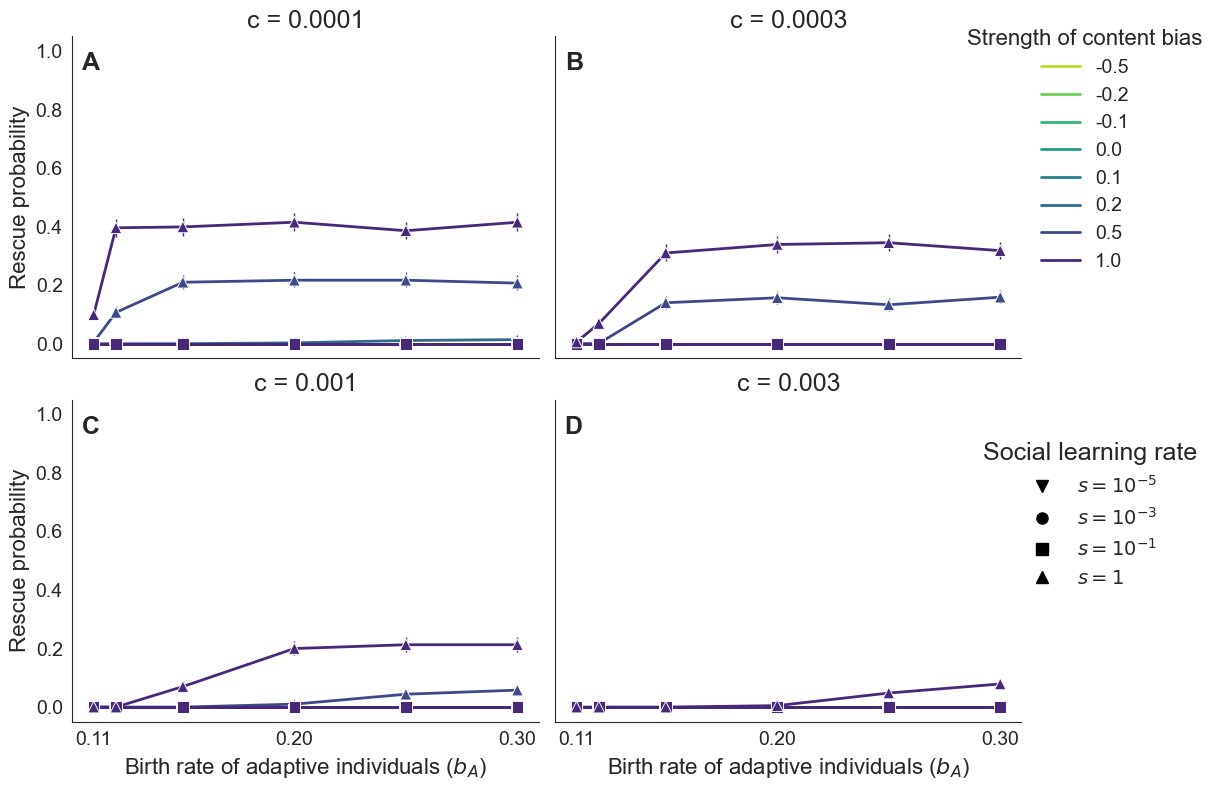

In [9]:
Plot_dynamics(bias_type=0)

### Table S2
Statistical analysis on how the parameters affect the rescue probability under content-biased social learning

In [12]:
# statistical analysis
import numpy as np
import pandas as pd
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("Python version:", sys.version)
print("statsmodels version:", statsmodels.__version__)

df = pd.read_csv("Cultural_evolutionary_rescue_content.csv")
df["log10_mu"] = np.log10(df["mu"] + 1e-10)
df["log10_c"] = np.log10(df["c"])
df["log10_s"] = np.log10(df["s"])
df["log10_N0"] = np.log10(df["init_pop_size"])
df["rescue_prob"] = df["rescue"] / (df["rescue"] + df["extinction"])

glm = smf.glm(
    "rescue_prob ~ b_A + parm + log10_s + log10_mu + log10_c + log10_N0",
    data=df,
    family=sm.families.Binomial(),
    freq_weights=df["rescue"] + df["extinction"]
).fit()
coef_table = glm.summary2().tables[1]

print(coef_table.round(3))

Python version: 3.11.12 (main, Apr  8 2025, 14:15:29) [Clang 16.0.0 (clang-1600.0.26.6)]
statsmodels version: 0.14.4
            Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
Intercept -12.717     0.016 -775.559    0.0 -12.749 -12.685
b_A        24.385     0.030  809.540    0.0  24.325  24.444
parm        1.650     0.004  442.523    0.0   1.642   1.657
log10_s     0.192     0.001  219.837    0.0   0.190   0.193
log10_mu    1.410     0.002  894.691    0.0   1.407   1.413
log10_c    -2.287     0.004 -634.593    0.0  -2.294  -2.280
log10_N0    0.225     0.002  113.412    0.0   0.221   0.228


### Figure S3
Calibration plot for the above model

/var/folders/pd/r54tyyzj25j1d9xv8skmgd4r0000gn/T/ipykernel_51322/2199613711.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("bin")
/var/folders/pd/r54tyyzj25j1d9xv8skmgd4r0000gn/T/ipykernel_51322/2199613711.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


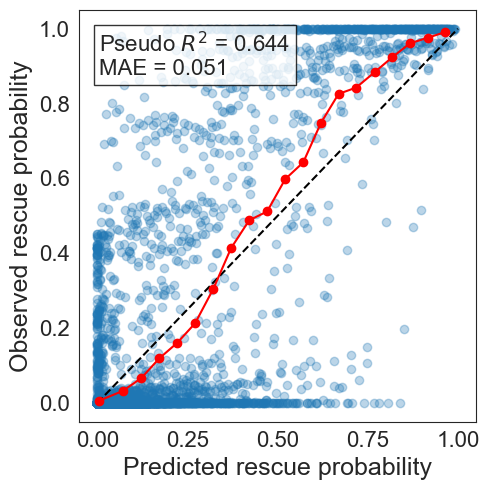

In [13]:
Calibration(df, glm, "Calibration_content.eps")

## Conformity bias
### Figure 4 
Conformity bias hinders evolutionary rescue

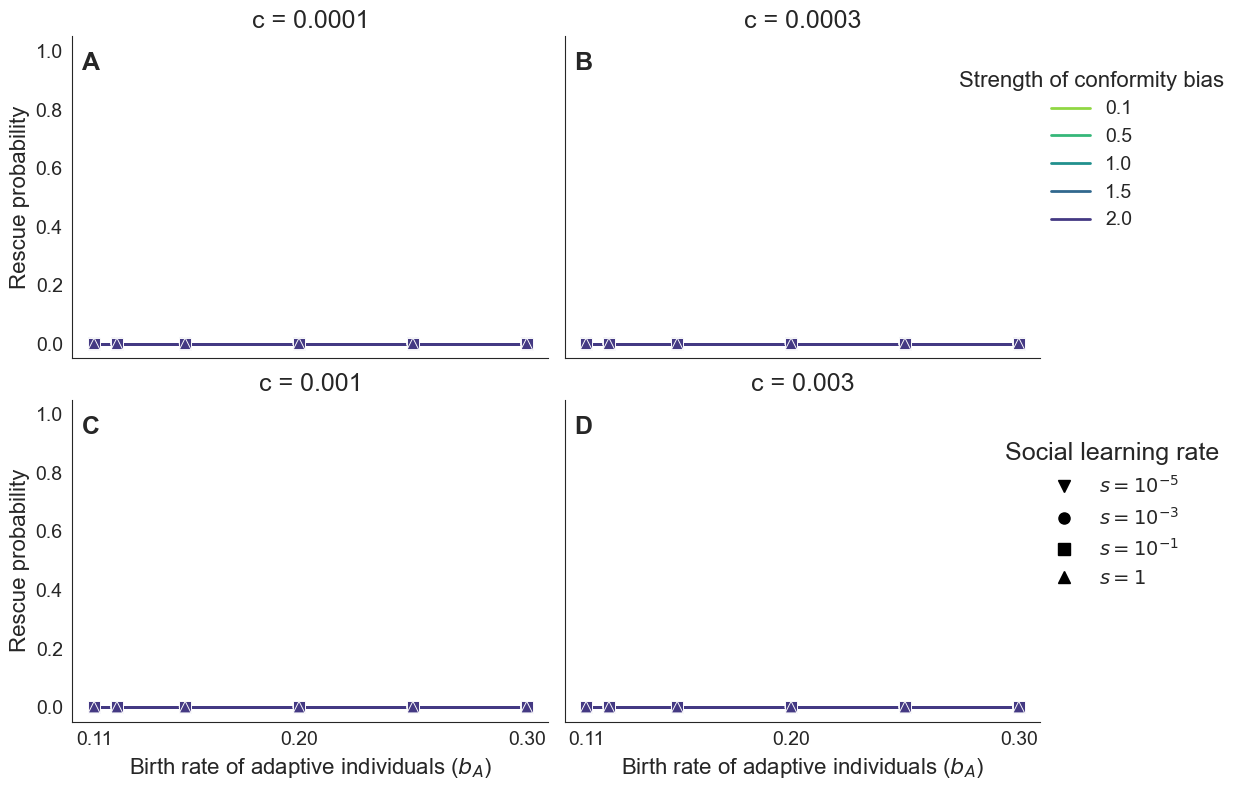

In [14]:
Plot_dynamics(bias_type=1)

### Table S3
Statistical analysis on how the parameters affect the rescue probability under conformity-biased social learning

In [15]:
# statistical analysis
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf



df = pd.read_csv("Cultural_evolutionary_rescue_conformity.csv")
df["log10_mu"] = np.log10(df["mu"] + 1e-10)
df["log10_c"] = np.log10(df["c"])
df["log10_s"] = np.log10(df["s"])
df["log10_N0"] = np.log10(df["init_pop_size"])
df["rescue_prob"] = df["rescue"] / (df["rescue"] + df["extinction"])

glm = smf.glm(
    "rescue_prob ~ b_A + parm + log10_s + log10_mu + log10_c + log10_N0",
    data=df,
    family=sm.families.Binomial(),
    freq_weights=df["rescue"] + df["extinction"]
).fit()
coef_table = glm.summary2().tables[1]

print(coef_table.round(3))

            Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
Intercept -19.938     0.068 -292.761    0.0 -20.071 -19.804
b_A        41.701     0.083  501.037    0.0  41.538  41.865
parm       -0.431     0.005  -88.277    0.0  -0.441  -0.422
log10_s    -0.564     0.002 -288.501    0.0  -0.568  -0.560
log10_mu    5.811     0.050  116.352    0.0   5.713   5.909
log10_c    -4.013     0.009 -434.337    0.0  -4.031  -3.994
log10_N0    0.334     0.004   82.315    0.0   0.326   0.341


### Figure S4
Calibration plot for the above model

/var/folders/pd/r54tyyzj25j1d9xv8skmgd4r0000gn/T/ipykernel_51322/2199613711.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("bin")
/var/folders/pd/r54tyyzj25j1d9xv8skmgd4r0000gn/T/ipykernel_51322/2199613711.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


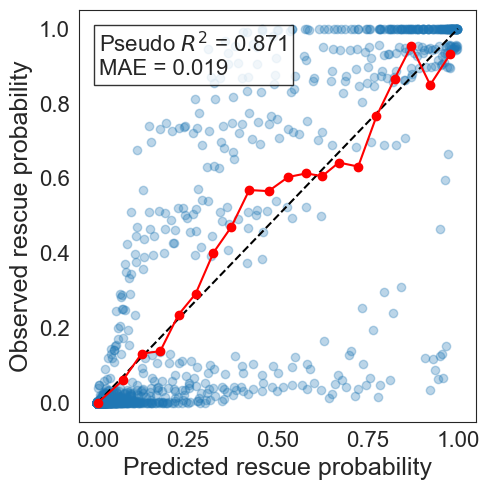

In [16]:
Calibration(df, glm, "Calibration_conformity.eps")

## Anticonformity bias
### Figure 5
Anticonformity bias promotes evolutionary rescue

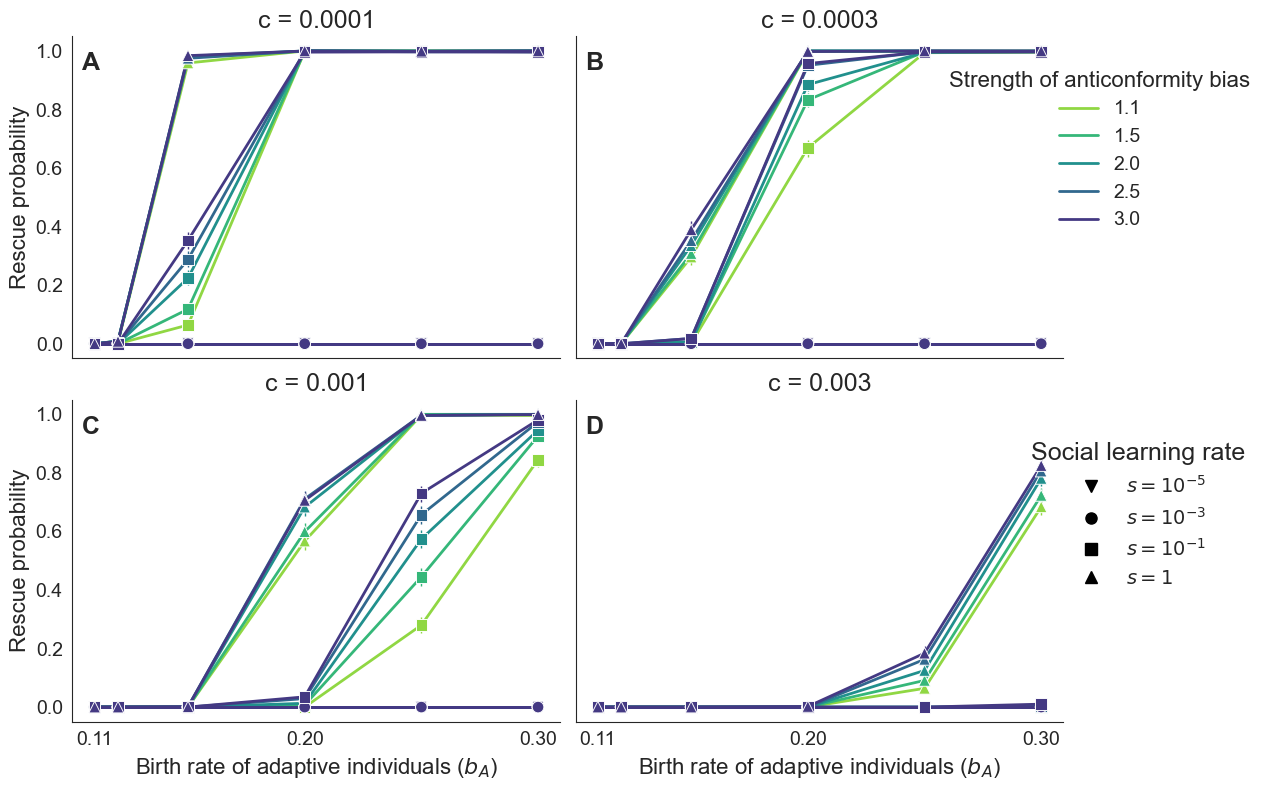

In [17]:
Plot_dynamics(bias_type=2)

### Table S4
Statistical analysis on how the parameters affect the rescue probability under anticonformity-biased social learning

In [18]:
# statistical analysis
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf



df = pd.read_csv("Cultural_evolutionary_rescue_anticonformity.csv")
df["log10_mu"] = np.log10(df["mu"] + 1e-10)
df["log10_c"] = np.log10(df["c"])
df["log10_s"] = np.log10(df["s"])
df["log10_N0"] = np.log10(df["init_pop_size"])
df["rescue_prob"] = df["rescue"] / (df["rescue"] + df["extinction"])

glm = smf.glm(
    "rescue_prob ~ b_A + parm + log10_s + log10_mu + log10_c + log10_N0",
    data=df,
    family=sm.families.Binomial(),
    freq_weights=df["rescue"] + df["extinction"]
).fit()
coef_table = glm.summary2().tables[1]

print(coef_table.round(3))

            Coef.  Std.Err.         z  P>|z|  [0.025  0.975]
Intercept -16.569     0.018  -944.492    0.0 -16.603 -16.534
b_A        35.110     0.033  1068.286    0.0  35.045  35.174
parm        0.137     0.002    64.341    0.0   0.133   0.141
log10_s     1.251     0.001   955.535    0.0   1.249   1.254
log10_mu    0.224     0.001   417.241    0.0   0.223   0.225
log10_c    -2.880     0.004  -818.979    0.0  -2.887  -2.873
log10_N0    0.329     0.002   183.671    0.0   0.325   0.332


### Figure S5
Calibration plot for the above model

/var/folders/pd/r54tyyzj25j1d9xv8skmgd4r0000gn/T/ipykernel_51322/2199613711.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("bin")
/var/folders/pd/r54tyyzj25j1d9xv8skmgd4r0000gn/T/ipykernel_51322/2199613711.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


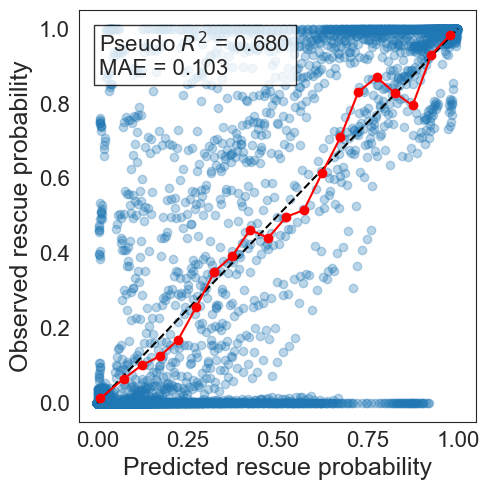

In [19]:
Calibration(df, glm, "Calibration_anticonformity.eps")

# Comparison of the rescue probability between biological and cultural evolution models
## Figure 6 shows anticonformity bias outperforms biological evolution in many paraneter areas.
The iniital population size 1000.

In [21]:
# Data processing
import numpy as np
import pandas as pd
from scipy.stats import beta

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def delta_rescue_beta_ci(
    rescue_s, extinct_s,
    rescue_b, extinct_b,
    alpha=0.05,
    n_sample=20000
):
    """
    Difference of rescue probabilities between
    social learning and biological evolution (max μ),
    with Bayesian credible interval.
    """

    # Beta(1,1) prior
    a_s = 1 + rescue_s
    b_s = 1 + extinct_s

    a_b = 1 + rescue_b
    b_b = 1 + extinct_b

    # posterior sampling
    ps = beta.rvs(a_s, b_s, size=n_sample)
    pb = beta.rvs(a_b, b_b, size=n_sample)

    delta = ps - pb

    return pd.Series({
        "delta": delta.mean(),
        "ci_lower": np.quantile(delta, alpha / 2),
        "ci_upper": np.quantile(delta, 1 - alpha / 2)
    })

def Plot_diff_rescue(init_pop=1000, mu=1e-3, ind_learning_rate=0):
    df_biol = pd.read_csv("Biological_evolutionary_rescue.csv")
    df_cont = pd.read_csv("Cultural_evolutionary_rescue_content.csv")
    df_conformity = pd.read_csv("Cultural_evolutionary_rescue_conformity.csv")
    df_anti = pd.read_csv("Cultural_evolutionary_rescue_anticonformity.csv")

    # Get subset
    df_biol = df_biol[(df_biol["init_pop_size"] == init_pop) &
                (df_biol["mu"] == mu)
                ].copy()
    df_cont = df_cont[(df_cont["init_pop_size"] == init_pop) &
                (df_cont["mu"] == ind_learning_rate)
                ].copy()
    df_conformity = df_conformity[(df_conformity["init_pop_size"] == init_pop) &
                    (df_conformity["mu"] == ind_learning_rate)
                    ].copy()
    df_anti = df_anti[(df_anti["init_pop_size"] == init_pop) &
                (df_anti["mu"] == ind_learning_rate)
                ].copy()

    # --- Helper for one bias ---
    def compute_delta(df_social, label):
        records = []

        for _, row in df_social.iterrows():

            # match biological baseline by (c, b_A)
            df_b = df_biol[
                (df_biol["c"] == row["c"]) &
                (df_biol["b_A"] == row["b_A"])
            ]

            if len(df_b) == 0:
                continue

            bio = df_b.iloc[0]

            res = delta_rescue_beta_ci(
                rescue_s=row["rescue"],
                extinct_s=row["extinction"],
                rescue_b=bio["rescue"],
                extinct_b=bio["extinction"]
            )

            records.append({
                "bias": label,
                "c": row["c"],
                "b_A": row["b_A"],
                "parm": row.get("parm", np.nan),
                "s": row.get("s", np.nan),
                "delta_rescue": res["delta"],
                "ci_lower": res["ci_lower"],
                "ci_upper": res["ci_upper"]
            })

        return pd.DataFrame(records)

    # --- Compute all ---
    df_delta_cont = compute_delta(df_cont, "content")
    df_delta_conf = compute_delta(df_conformity, "conformity")
    df_delta_anti = compute_delta(df_anti, "anticonformity")

    df_delta_all = pd.concat(
        [df_delta_cont, df_delta_conf, df_delta_anti],
        ignore_index=True
    )

    return df_delta_all
df_delta_all=Plot_diff_rescue()

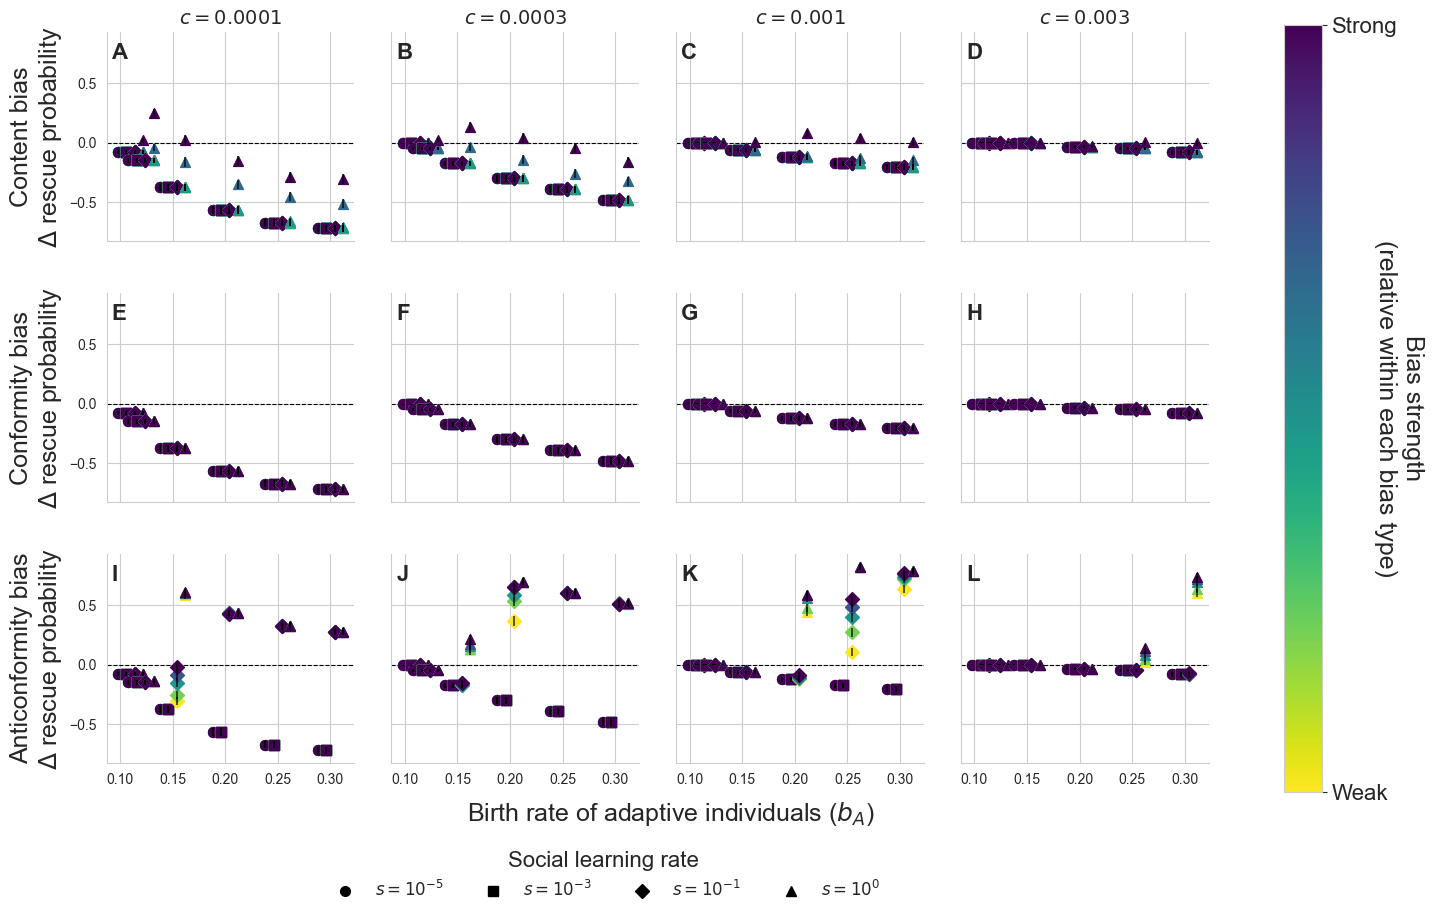

In [22]:
# ============================================================
# Delta rescue probability plot
# rows = bias type, cols = c
# marker = social learning rate
# color = bias strength (normalized within bias)
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib as mpl
import string


def normalize_parm_within_bias(df):
    df = df.copy()
    df["parm_norm"] = (
        df.groupby("bias")["parm"]
          .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
    )
    return df


df_plot = normalize_parm_within_bias(df_delta_all)


sns.set_style("whitegrid")

bias_order = ["content", "conformity", "anticonformity"]
c_order = sorted(df_plot["c"].unique())

bias_titles = {
    "content": "Content bias",
    "conformity": "Conformity bias",
    "anticonformity": "Anticonformity bias"
}

marker_cycle = ["o", "s", "D", "^", "v", "P", "X"]


g = sns.FacetGrid(
    df_plot,
    row="bias",
    col="c",
    row_order=bias_order,
    col_order=c_order,
    sharex=True,
    sharey=True,
    height=2.8,
    aspect=1.2
)

def scatter_delta_with_ci(data, **kwargs):
    ax = plt.gca()

    # social learning rate ごとの dodge
    s_values = sorted(data["s"].unique())
    n_s = len(s_values)
    dodge_width = 0.012
    offsets = np.linspace(-dodge_width, dodge_width, n_s)
    dodge_dict = dict(zip(s_values, offsets))

    # marker: social learning rate
    marker_dict = {
        s: marker_cycle[i % len(marker_cycle)]
        for i, s in enumerate(s_values)
    }

    for _, r in data.iterrows():
        x = r["b_A"] + dodge_dict[r["s"]]

        # 95% CI
        ax.vlines(
            x,
            r["ci_lower"],
            r["ci_upper"],
            color="black",
            alpha=0.7,
            linewidth=1.3,
            zorder=3
        )

        # point
        ax.scatter(
            x,
            r["delta_rescue"],
            marker=marker_dict[r["s"]],
            s=50,
            c=r["parm_norm"],
            cmap="viridis_r",
            vmin=0,
            vmax=1,
            zorder=2
        )
    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
        zorder=1
    )


g.map_dataframe(scatter_delta_with_ci)
for ax, cval in zip(g.axes[0], c_order):
    ax.set_title(rf"$c = {cval}$", fontsize=16)
for ax in g.axes.flat[len(c_order):]:
    ax.set_title("")



panel_labels = string.ascii_uppercase  

axes = g.axes.flat 

for ax, label in zip(axes, panel_labels):
    ax.text(
        0.02, 0.95,          
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left"
    )

g.set_axis_labels(
    r"Birth rate of adaptive phenotype ($b_A$)",
    r"$\Delta$ rescue probability"
)



for ax, key in zip(g.axes[:, 0], bias_order):
    ax.set_ylabel(
        bias_titles[key] + "\n" + r"$\Delta$ rescue probability",
        fontsize=18
    )

for ax, cval in zip(g.axes[0], c_order):
    ax.set_title(rf"$c = {cval}$", fontsize=14)
# --- 各パネルの x ラベルを消す ---
for ax in g.axes.flat:
    ax.set_xlabel("")
g.fig.text(
    0.5,            
    0.02,         
    r"Birth rate of adaptive individuals ($b_A$)",
    ha="center",
    va="center",
    fontsize=18     
)




# --- (A) social learning rate ---
def sci_notation(x):
    exp = int(np.log10(x))
    return rf"$s = 10^{{{exp}}}$"


s_vals_all = sorted(df_plot["s"].unique())
handles_s = [
    Line2D(
        [0], [0],
        marker=marker_cycle[i % len(marker_cycle)],
        linestyle="None",
        color="black",
        markersize=7,
        label=sci_notation(s)
    )
    for i, s in enumerate(s_vals_all)
]

# --- Social learning rate legend (bottom) ---
g.fig.legend(
    handles=handles_s,
    title="Social learning rate",
    loc="lower center",
    bbox_to_anchor=(0.45, -0.1),
    ncol=len(handles_s),    
    frameon=False,
    prop={"size": 12},
    title_fontsize=16
)

# --- (B) bias strength colorbar ---
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis_r")
sm.set_array([])

cbar = g.fig.colorbar(
    sm,
    ax=g.axes,
    fraction=0.035,
    pad=0.01
)

cbar.ax.set_ylabel(
    "Bias strength\n(relative within each bias type)",
    fontsize=18,
    rotation=270,   
    labelpad= 1   
)
cbar.ax.yaxis.label.set_verticalalignment("center")

cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Weak", "Strong"])
cbar.ax.tick_params(labelsize=16)


#
g.fig.subplots_adjust(
    left=0.08,
    right=0.9,   
    bottom=0.08,
    top=0.95,
    hspace=0.25,
    wspace=0.15
)

#g.fig.savefig(
#     "Delta_rescue_probability_bias_by_c_init_pop_1000_ind_learning_0.pdf",
#     dpi=300,
#     bbox_inches="tight")

plt.show()

## Figure S8
The initial population size is 100.

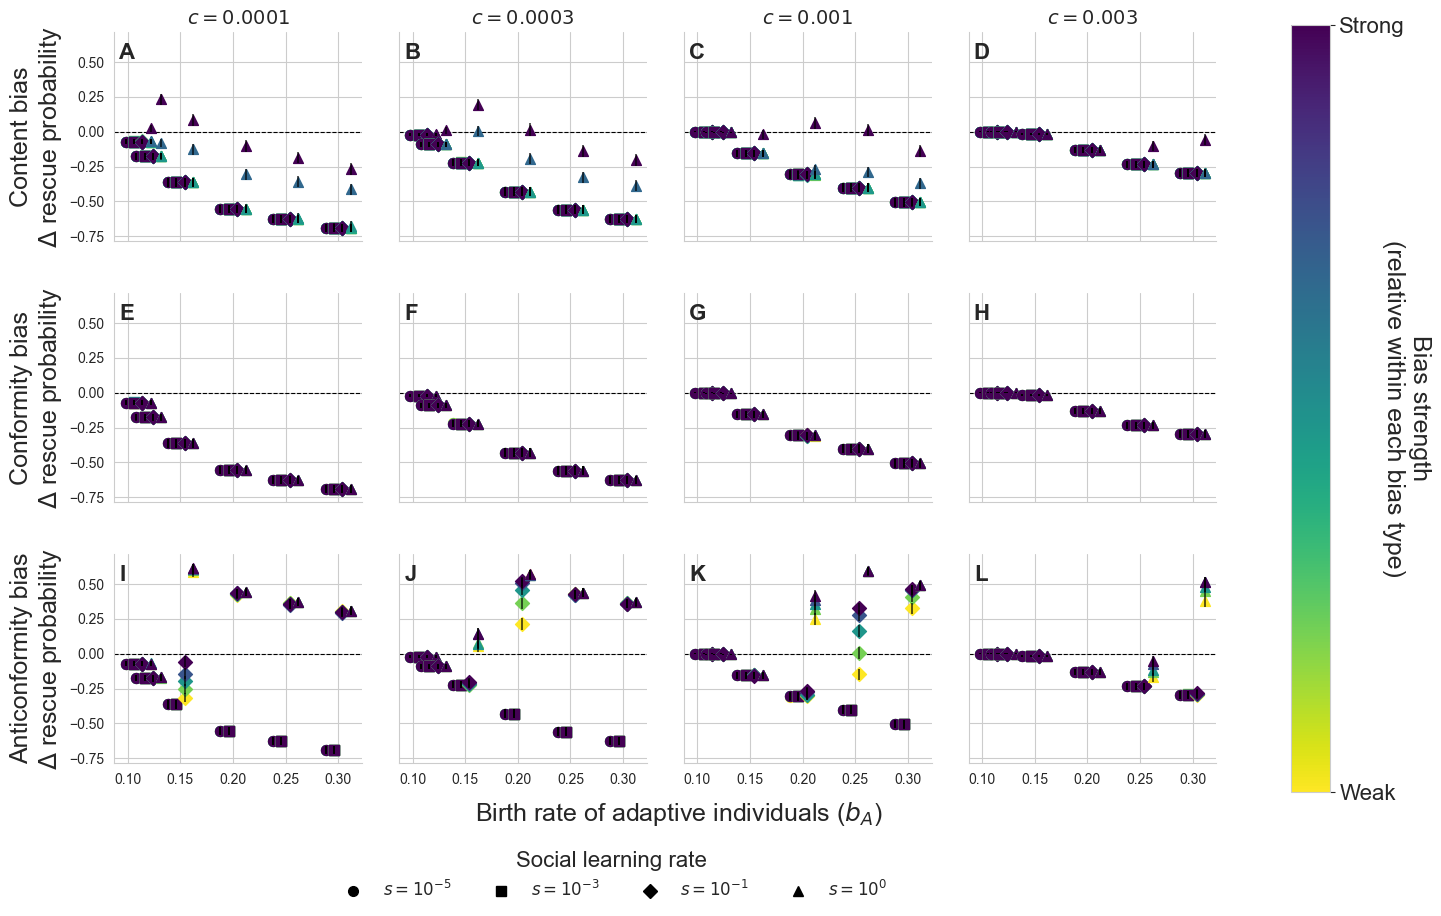

In [23]:
df_delta_all=Plot_diff_rescue(init_pop=100)

# ============================================================
# Delta rescue probability plot
# rows = bias type, cols = c
# marker = social learning rate
# color = bias strength (normalized within bias)
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib as mpl
import string


def normalize_parm_within_bias(df):
    df = df.copy()
    df["parm_norm"] = (
        df.groupby("bias")["parm"]
          .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
    )
    return df


df_plot = normalize_parm_within_bias(df_delta_all)


sns.set_style("whitegrid")

bias_order = ["content", "conformity", "anticonformity"]
c_order = sorted(df_plot["c"].unique())

bias_titles = {
    "content": "Content bias",
    "conformity": "Conformity bias",
    "anticonformity": "Anticonformity bias"
}

marker_cycle = ["o", "s", "D", "^", "v", "P", "X"]


g = sns.FacetGrid(
    df_plot,
    row="bias",
    col="c",
    row_order=bias_order,
    col_order=c_order,
    sharex=True,
    sharey=True,
    height=2.8,
    aspect=1.2
)

def scatter_delta_with_ci(data, **kwargs):
    ax = plt.gca()

    # social learning rate ごとの dodge
    s_values = sorted(data["s"].unique())
    n_s = len(s_values)
    dodge_width = 0.012
    offsets = np.linspace(-dodge_width, dodge_width, n_s)
    dodge_dict = dict(zip(s_values, offsets))

    # marker: social learning rate
    marker_dict = {
        s: marker_cycle[i % len(marker_cycle)]
        for i, s in enumerate(s_values)
    }

    for _, r in data.iterrows():
        x = r["b_A"] + dodge_dict[r["s"]]

        # 95% CI
        ax.vlines(
            x,
            r["ci_lower"],
            r["ci_upper"],
            color="black",
            alpha=0.7,
            linewidth=1.3,
            zorder=3
        )

        # point
        ax.scatter(
            x,
            r["delta_rescue"],
            marker=marker_dict[r["s"]],
            s=50,
            c=r["parm_norm"],
            cmap="viridis_r",
            vmin=0,
            vmax=1,
            zorder=2
        )
    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
        zorder=1
    )


g.map_dataframe(scatter_delta_with_ci)
for ax, cval in zip(g.axes[0], c_order):
    ax.set_title(rf"$c = {cval}$", fontsize=16)
for ax in g.axes.flat[len(c_order):]:
    ax.set_title("")



panel_labels = string.ascii_uppercase  

axes = g.axes.flat 

for ax, label in zip(axes, panel_labels):
    ax.text(
        0.02, 0.95,          
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left"
    )

g.set_axis_labels(
    r"Birth rate of adaptive phenotype ($b_A$)",
    r"$\Delta$ rescue probability"
)



for ax, key in zip(g.axes[:, 0], bias_order):
    ax.set_ylabel(
        bias_titles[key] + "\n" + r"$\Delta$ rescue probability",
        fontsize=18
    )

for ax, cval in zip(g.axes[0], c_order):
    ax.set_title(rf"$c = {cval}$", fontsize=14)
# --- 各パネルの x ラベルを消す ---
for ax in g.axes.flat:
    ax.set_xlabel("")
g.fig.text(
    0.5,            
    0.02,         
    r"Birth rate of adaptive individuals ($b_A$)",
    ha="center",
    va="center",
    fontsize=18     
)




# --- (A) social learning rate ---
def sci_notation(x):
    exp = int(np.log10(x))
    return rf"$s = 10^{{{exp}}}$"


s_vals_all = sorted(df_plot["s"].unique())
handles_s = [
    Line2D(
        [0], [0],
        marker=marker_cycle[i % len(marker_cycle)],
        linestyle="None",
        color="black",
        markersize=7,
        label=sci_notation(s)
    )
    for i, s in enumerate(s_vals_all)
]

# --- Social learning rate legend (bottom) ---
g.fig.legend(
    handles=handles_s,
    title="Social learning rate",
    loc="lower center",
    bbox_to_anchor=(0.45, -0.1),
    ncol=len(handles_s),    
    frameon=False,
    prop={"size": 12},
    title_fontsize=16
)

# --- (B) bias strength colorbar ---
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis_r")
sm.set_array([])

cbar = g.fig.colorbar(
    sm,
    ax=g.axes,
    fraction=0.035,
    pad=0.01
)

cbar.ax.set_ylabel(
    "Bias strength\n(relative within each bias type)",
    fontsize=18,
    rotation=270,   
    labelpad= 1   
)
cbar.ax.yaxis.label.set_verticalalignment("center")

cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Weak", "Strong"])
cbar.ax.tick_params(labelsize=16)


#
g.fig.subplots_adjust(
    left=0.08,
    right=0.9,   
    bottom=0.08,
    top=0.95,
    hspace=0.25,
    wspace=0.15
)

#g.fig.savefig(
#     "Delta_rescue_probability_bias_by_c_init_pop_100_ind_learning_0.pdf",
#     dpi=300,
#     bbox_inches="tight")

plt.show()

## Figure S9
The initial population size is 10.

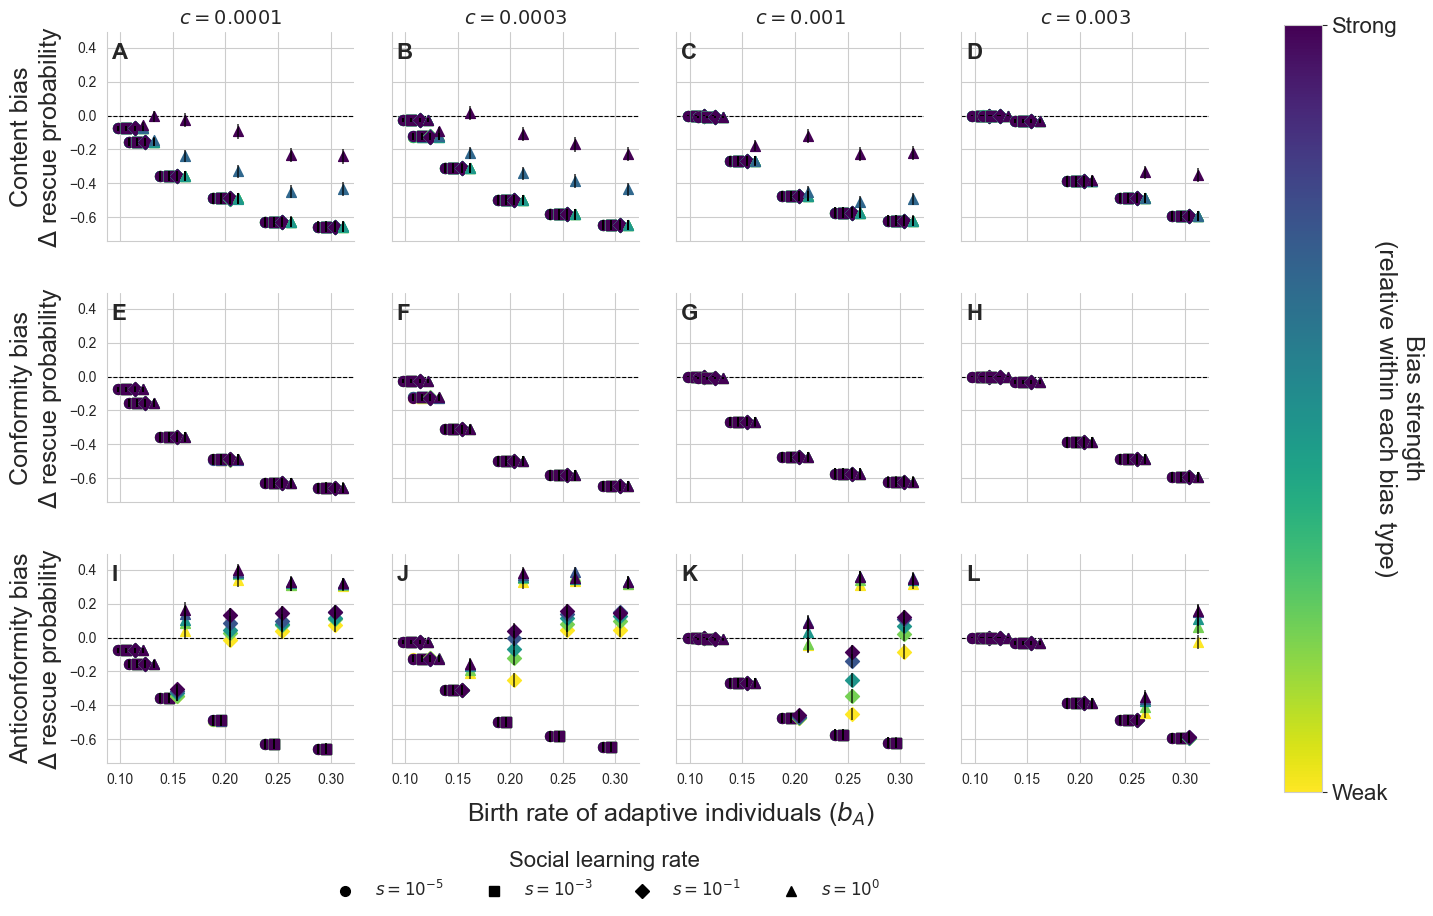

In [24]:
df_delta_all=Plot_diff_rescue(init_pop=10)

# ============================================================
# Delta rescue probability plot
# rows = bias type, cols = c
# marker = social learning rate
# color = bias strength (normalized within bias)
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib as mpl
import string


def normalize_parm_within_bias(df):
    df = df.copy()
    df["parm_norm"] = (
        df.groupby("bias")["parm"]
          .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
    )
    return df


df_plot = normalize_parm_within_bias(df_delta_all)


sns.set_style("whitegrid")

bias_order = ["content", "conformity", "anticonformity"]
c_order = sorted(df_plot["c"].unique())

bias_titles = {
    "content": "Content bias",
    "conformity": "Conformity bias",
    "anticonformity": "Anticonformity bias"
}

marker_cycle = ["o", "s", "D", "^", "v", "P", "X"]


g = sns.FacetGrid(
    df_plot,
    row="bias",
    col="c",
    row_order=bias_order,
    col_order=c_order,
    sharex=True,
    sharey=True,
    height=2.8,
    aspect=1.2
)

def scatter_delta_with_ci(data, **kwargs):
    ax = plt.gca()

    # social learning rate ごとの dodge
    s_values = sorted(data["s"].unique())
    n_s = len(s_values)
    dodge_width = 0.012
    offsets = np.linspace(-dodge_width, dodge_width, n_s)
    dodge_dict = dict(zip(s_values, offsets))

    # marker: social learning rate
    marker_dict = {
        s: marker_cycle[i % len(marker_cycle)]
        for i, s in enumerate(s_values)
    }

    for _, r in data.iterrows():
        x = r["b_A"] + dodge_dict[r["s"]]

        # 95% CI
        ax.vlines(
            x,
            r["ci_lower"],
            r["ci_upper"],
            color="black",
            alpha=0.7,
            linewidth=1.3,
            zorder=3
        )

        # point
        ax.scatter(
            x,
            r["delta_rescue"],
            marker=marker_dict[r["s"]],
            s=50,
            c=r["parm_norm"],
            cmap="viridis_r",
            vmin=0,
            vmax=1,
            zorder=2
        )
    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
        zorder=1
    )


g.map_dataframe(scatter_delta_with_ci)
for ax, cval in zip(g.axes[0], c_order):
    ax.set_title(rf"$c = {cval}$", fontsize=16)
for ax in g.axes.flat[len(c_order):]:
    ax.set_title("")



panel_labels = string.ascii_uppercase  

axes = g.axes.flat 

for ax, label in zip(axes, panel_labels):
    ax.text(
        0.02, 0.95,          
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left"
    )

g.set_axis_labels(
    r"Birth rate of adaptive phenotype ($b_A$)",
    r"$\Delta$ rescue probability"
)



for ax, key in zip(g.axes[:, 0], bias_order):
    ax.set_ylabel(
        bias_titles[key] + "\n" + r"$\Delta$ rescue probability",
        fontsize=18
    )

for ax, cval in zip(g.axes[0], c_order):
    ax.set_title(rf"$c = {cval}$", fontsize=14)
# --- 各パネルの x ラベルを消す ---
for ax in g.axes.flat:
    ax.set_xlabel("")
g.fig.text(
    0.5,            
    0.02,         
    r"Birth rate of adaptive individuals ($b_A$)",
    ha="center",
    va="center",
    fontsize=18     
)




# --- (A) social learning rate ---
def sci_notation(x):
    exp = int(np.log10(x))
    return rf"$s = 10^{{{exp}}}$"


s_vals_all = sorted(df_plot["s"].unique())
handles_s = [
    Line2D(
        [0], [0],
        marker=marker_cycle[i % len(marker_cycle)],
        linestyle="None",
        color="black",
        markersize=7,
        label=sci_notation(s)
    )
    for i, s in enumerate(s_vals_all)
]

# --- Social learning rate legend (bottom) ---
g.fig.legend(
    handles=handles_s,
    title="Social learning rate",
    loc="lower center",
    bbox_to_anchor=(0.45, -0.1),
    ncol=len(handles_s),    
    frameon=False,
    prop={"size": 12},
    title_fontsize=16
)

# --- (B) bias strength colorbar ---
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis_r")
sm.set_array([])

cbar = g.fig.colorbar(
    sm,
    ax=g.axes,
    fraction=0.035,
    pad=0.01
)

cbar.ax.set_ylabel(
    "Bias strength\n(relative within each bias type)",
    fontsize=18,
    rotation=270,   
    labelpad= 1   
)
cbar.ax.yaxis.label.set_verticalalignment("center")

cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Weak", "Strong"])
cbar.ax.tick_params(labelsize=16)


#
g.fig.subplots_adjust(
    left=0.08,
    right=0.9,   
    bottom=0.08,
    top=0.95,
    hspace=0.25,
    wspace=0.15
)

#g.fig.savefig(
#     "Delta_rescue_probability_bias_by_c_init_pop_10_ind_learning_0.pdf",
#     dpi=300,
#     bbox_inches="tight")

plt.show()

# Relationship between the establishment time difference and rescue probability difference
## Figure 7
The initial population size is 1000

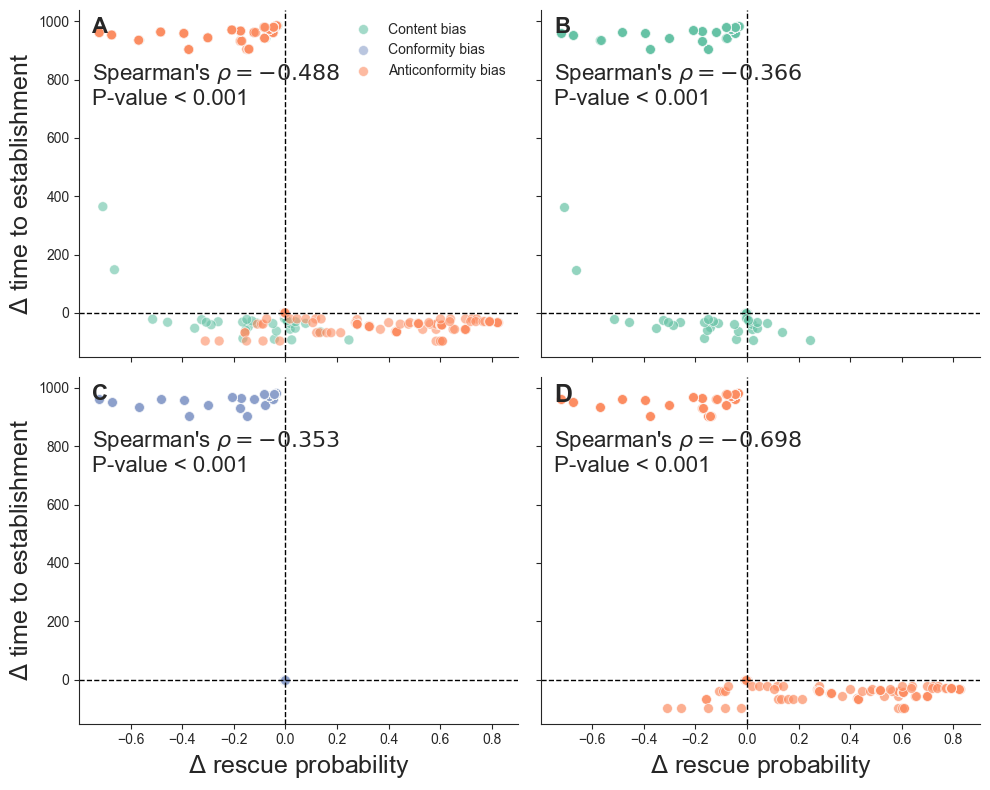

In [25]:
from scipy import stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

mu=1e-3 # maximize the biological evolutionary rescue probability
init_pop = 1e3 # fixed in the main text
ind_learning_rate=0 # fixed in the main text figure 
df_biol = pd.read_csv("Biological_evolutionary_rescue.csv")
df_cont = pd.read_csv("Cultural_evolutionary_rescue_content.csv")
df_conformity = pd.read_csv("Cultural_evolutionary_rescue_conformity.csv")
df_anti = pd.read_csv("Cultural_evolutionary_rescue_anticonformity.csv")

df_biol = df_biol[(df_biol["init_pop_size"] == init_pop) &
                (df_biol["mu"] == mu)
                ].copy()
df_cont = df_cont[(df_cont["init_pop_size"] == init_pop) &
                (df_cont["mu"] == ind_learning_rate)
                ].copy()
df_conformity = df_conformity[(df_conformity["init_pop_size"] == init_pop) &
                    (df_conformity["mu"] == ind_learning_rate)
                    ].copy()
df_anti = df_anti[(df_anti["init_pop_size"] == init_pop) &
                (df_anti["mu"] == ind_learning_rate)
                ].copy()

palette = {
"Content bias": "#66c2a5",
"Conformity bias": "#8da0cb", # orange
"Anticonformity bias": "#fc8d62" # green
}

def Diff_establish_time(
        df_biol,
        df_cul,
        rescue_prob_threshold=0.01,
        iteration=1000,
        Tf=1000):

    df_biol = df_biol.copy()
    df_cul = df_cul.copy()

    df_biol.loc[
        df_biol["rescue"] < rescue_prob_threshold * iteration,
        "mean_rescue_time"
    ] = Tf

    df_cul.loc[
        df_cul["rescue"] < rescue_prob_threshold * iteration,
        "mean_rescue_time"
    ] = Tf

    df_new = df_cul.merge(
        df_biol,
        on=["b_A", "c"],
        suffixes=("_cul", "_biol")
    )

    df_new["delta_T"] = (
        df_new["mean_rescue_time_cul"]
        - df_new["mean_rescue_time_biol"]
    )

    df_new["delta_P"] = (
        df_new["rescue_cul"]
        - df_new["rescue_biol"]
    ) / iteration

    return df_new


def spearman_label(df):

    rho, p = stats.spearmanr(
        df["delta_T"],
        df["delta_P"]
    )

    if p < 0.001:
        txt = (
            rf"$\rho$ = {rho:.3f}" + "\n"
            r"$P < 0.001$"
        )
    else:
        txt = (
            rf"$\rho$ = {rho:.3f}" + "\n"
            + rf"$P = {p:.3f}$"
        )

    return txt

df_cont2 = Diff_establish_time(df_biol, df_cont)
df_cont2["bias"] = "Content bias"

df_conformity2 = Diff_establish_time(df_biol, df_conformity)
df_conformity2["bias"] = "Conformity bias"

df_anti2 = Diff_establish_time(df_biol, df_anti)
df_anti2["bias"] = "Anticonformity bias"

df_delta = pd.concat(
    [df_cont2, df_conformity2, df_anti2],
    ignore_index=True
)


# =========================
# Plot settings
# =========================

sns.set_style("ticks")

# =========================
# Helper function
# =========================

def add_corr_text(ax, df):

    rho, p = stats.spearmanr(
        df["delta_T"],
        df["delta_P"]
    )

    if p < 0.001:
        p_text = "P-value < 0.001"
    else:
        p_text = f"P-value = {p:.3f}"

    ax.text(
        0.03,
        0.85,
        rf"Spearman's $\rho = {rho:.3f}$" + "\n" + p_text,
        transform=ax.transAxes,
        va="top",
        fontsize=16
    )


# =========================
# 2 x 2 panel figure
# =========================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 8),
    sharex=True,
    sharey=True
)

# -------------------------
# Panel A
# -------------------------

ax = axes[0, 0]

sns.scatterplot(
    data=df_delta,
    x="delta_P",
    y="delta_T",
    hue="bias",
    palette=palette,
    alpha=0.6,
    s=50,
    ax=ax
)

ax.text(
    0.03,
    0.98,
    "A",
    transform=ax.transAxes,
    va="top",
    fontsize=16,
    fontweight="bold"
)

add_corr_text(ax, df_delta)
ax.axvline(
    0,
    color="black",
    linestyle="dashed",
    linewidth=1
)

ax.axhline(
    0,
    color="black",
    linestyle="dashed",
    linewidth=1
)

ax.grid(False)

# -------------------------
# Panel B
# -------------------------

ax = axes[0, 1]

sns.scatterplot(
    data=df_cont2,
    x="delta_P",
    y="delta_T",
    color=palette["Content bias"],
    alpha=0.7,
    s=50,
    ax=ax
)

ax.text(
    0.03,
    0.98,
    "B",
    transform=ax.transAxes,
    va="top",
    fontsize=16,
    fontweight="bold"
)

add_corr_text(ax, df_cont2)
ax.axvline(
    0,
    color="black",
    linestyle="dashed",
    linewidth=1
)

ax.axhline(
    0,
    color="black",
    linestyle="dashed",
    linewidth=1
)
ax.grid(False)

# -------------------------
# Panel C
# -------------------------

ax = axes[1, 0]

sns.scatterplot(
    data=df_conformity2,
    x="delta_P",
    y="delta_T",
    color=palette["Conformity bias"],
    alpha=0.7,
    s=50,
    ax=ax
)

ax.text(
    0.03,
    0.98,
    "C",
    transform=ax.transAxes,
    va="top",
    fontsize=16,
    fontweight="bold"
)

add_corr_text(ax, df_conformity2)
ax.axvline(
    0,
    color="black",
    linestyle="dashed",
    linewidth=1
)

ax.axhline(
    0,
    color="black",
    linestyle="dashed",
    linewidth=1
)
ax.grid(False)

# -------------------------
# Panel D
# -------------------------

ax = axes[1, 1]

sns.scatterplot(
    data=df_anti2,
    x="delta_P",
    y="delta_T",
    color=palette["Anticonformity bias"],
    alpha=0.7,
    s=50,
    ax=ax
)

ax.text(
    0.03,
    0.98,
    "D",
    transform=ax.transAxes,
    va="top",
    fontsize=18,
    fontweight="bold"
)

add_corr_text(ax, df_anti2)
ax.axvline(
    0,
    color="black",
    linestyle="dashed",
    linewidth=1
)

ax.axhline(
    0,
    color="black",
    linestyle="dashed",
    linewidth=1
)
ax.grid(False)

# =========================
# Shared formatting
# =========================

# remove legends from B-D
for ax in [axes[0,1], axes[1,0], axes[1,1]]:

    if ax.get_legend() is not None:
        ax.get_legend().remove()

# legend only in panel A
axes[0,0].legend(
    title="",
    frameon=False,
    loc="best"
)

for ax in axes.ravel():

    sns.despine(ax=ax)

    ax.set_xlabel(
        r"$\Delta$ rescue probability",
        fontsize=18
    )

    ax.set_ylabel(
        r"$\Delta$ time to establishment",
        fontsize=18
    )

plt.tight_layout()
#plt.savefig("DeltaT_Delta_P_init_pop_1000_ind_learning_0.pdf")
plt.show()